## Import libs

In [1]:
from tensorflow.python.data import Dataset
from sklearn.model_selection import train_test_split
import seaborn as sns
import pandas as pd


from falsb4mpa.dataset.load_data import load_data
from falsb4mpa.evaluation.evaluation import compute_predictive_metrics, compute_fair_metrics, compute_tradeoff, compute_intersectional_fair_metrics
from falsb4mpa.modeling.sk_vanilla.vanilla_lr import VanillaLogisticRegression

## Preliminaries

In [2]:
batch_size = 64
epochs = 100
learning_rate = 0.001

In [3]:
# cv_seeds = [13]
cv_seeds = [13, 29, 42, 55, 73]

## Load data

In [4]:
data_name = 'adult-mpa-cat-wout-agg'

In [5]:
x, y, a1, a2 = load_data(data_name)
raw_data = (x, y, a1, a2)

In [6]:
xdim = x.shape[1]
ydim = y.shape[1]
a1dim = a1.shape[1]
a2dim = a2.shape[1]
zdim = 8
print(xdim, ydim, a1dim, a2dim, zdim)

102 1 1 5 8


## Result file

In [7]:
header = [
    "model_name", "cv_seed", 
    "clas_acc", "f1-micro", "f1-macro",
    "a1_dp", "a1_deqodds", "a1_deqopp",
    "a2_dp", "a2_deqodds", "a2_deqopp",
    "wc_spd", "wc_aod", "wc_eod"
]

results = []

## Testing

In [8]:
results= []
for cv_seed in cv_seeds:
        x_train, x_test, y_train, y_test, a1_train, a1_test, a2_train, a2_test = train_test_split(
                x, y, a1, a2, test_size=0.3, random_state=cv_seed
        )
        y_train = y_train.ravel()
        y_test = y_test.ravel()
        
        model = VanillaLogisticRegression(epochs, learning_rate)

        train_data = Dataset.from_tensor_slices((x_train, y_train, a1_train, a2_train))
        train_data = train_data.batch(batch_size, drop_remainder=True)

        test_data = Dataset.from_tensor_slices((x_test, y_test, a1_test, a2_test))
        test_data = test_data.batch(batch_size, drop_remainder=True)

        for epoch in range(epochs):
                for X, Y, A1, A2 in train_data:
                        model.partial_fit(X, Y)

         
        Y_hat = model.predict(x_test)

        clas_acc, clas_f1_micro, clas_f1_macro, confusion_matrix = compute_predictive_metrics(y_test, Y_hat)
        
        a1_dp, a1_deqodds, a1_deqopp, a1_metrics_g0, a1_metrics_g1 = compute_fair_metrics(y_test, a1_test, Y_hat, a1dim)
        a2_dp, a2_deqodds, a2_deqopp = compute_fair_metrics(y_test, a2_test, Y_hat, a2dim)

        wc_spd, wc_aod, wc_eod = compute_intersectional_fair_metrics(y_test, a1_test, a2_test, Y_hat, a1dim, a2dim)
        
        # fair_metrics = (dp, deqodds, deqopp)
        
        # tradeoff = []
        
        # for fair_metric in fair_metrics:
        #         tradeoff.append(compute_tradeoff(clas_acc, fair_metric))
        
        # result = ['UnfairLR-decay', cv_seed, clas_acc, dp, deqodds, deqopp, tradeoff[0], tradeoff[1], tradeoff[2]]

        result = ['SkVanillaLR', cv_seed]
        result += [clas_acc, clas_f1_micro, clas_f1_macro]
        result += [a1_dp, a1_deqodds, a1_deqopp]
        result += [a2_dp, a2_deqodds, a2_deqopp]
        result += [wc_spd, wc_aod, wc_eod]

        results.append(result)
        

2026-05-12 16:18:47.505061: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-05-12 16:18:47.585142: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-05-12 16:18:47.749112: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-05-12 16:18:48.074663: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-05-12 16:18:48.722088: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-05-12 16:18:50.111207: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-05-12 16:18:52.741325: I tensorflow/core/framework/local_rendezvous.cc:405] L

> Predictive Performance Evaluation
> Class Acc = 0.8413060903549194
> Confusion Matrix 
TN: 9527.0 | FP: 682.0 
FN: 1471.0 | TP: 1887.0
> Fairness Evaluation
> DP | DEqOdds | DEqOpp
> 0.8193604350090027 | 0.8857139348983765 | 0.8485621213912964
> Confusion Matrix for A = 0 
TN: 5714.0 | FP: 608.0 
FN: 1181.0 | TP: 1665.0
> Confusion Matrix for A = 1 
TN: 3813.0 | FP: 74.0 
FN: 290.0 | TP: 222.0
> Fairness Evaluation
> DP | DEqOdds | DEqOpp
> 0.17372381687164307 | 0.2737741470336914 | 0.17372381687164307
> Intersectional Fairness Evaluation
> WC_SPD | WC_AOD | WC_EOD
> 0.6992714405059814 | 0.5855376124382019 | 0.1875


2026-05-12 16:18:58.071005: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
/Users/lffpl/Projects/falsb4mpa/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lffpl/Projects/falsb4mpa/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/lffpl/Projects/falsb4mpa/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


> Predictive Performance Evaluation
> Class Acc = 0.8408638834953308
> Confusion Matrix 
TN: 9496.0 | FP: 704.0 
FN: 1455.0 | TP: 1912.0
> Fairness Evaluation
> DP | DEqOdds | DEqOpp
> 0.8146132230758667 | 0.880408763885498 | 0.8399946093559265
> Confusion Matrix for A = 0 
TN: 5683.0 | FP: 626.0 
FN: 1167.0 | TP: 1693.0
> Confusion Matrix for A = 1 
TN: 3813.0 | FP: 78.0 
FN: 288.0 | TP: 219.0
> Fairness Evaluation
> DP | DEqOdds | DEqOpp
> 0.20381295680999756 | 0.2648904323577881 | 0.20381295680999756
> Intersectional Fairness Evaluation
> WC_SPD | WC_AOD | WC_EOD
> 0.6771250367164612 | 0.544623076915741 | 0.08333331346511841


2026-05-12 16:19:08.729524: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
/Users/lffpl/Projects/falsb4mpa/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lffpl/Projects/falsb4mpa/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/lffpl/Projects/falsb4mpa/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


> Predictive Performance Evaluation
> Class Acc = 0.844180703163147
> Confusion Matrix 
TN: 9444.0 | FP: 749.0 
FN: 1365.0 | TP: 2009.0
> Fairness Evaluation
> DP | DEqOdds | DEqOpp
> 0.8021386861801147 | 0.8808444142341614 | 0.8492447733879089
> Confusion Matrix for A = 0 
TN: 5580.0 | FP: 671.0 
FN: 1098.0 | TP: 1775.0
> Confusion Matrix for A = 1 
TN: 3864.0 | FP: 78.0 
FN: 267.0 | TP: 234.0
> Fairness Evaluation
> DP | DEqOdds | DEqOpp
> 0.2212982177734375 | 0.3072085976600647 | 0.2212982177734375
> Intersectional Fairness Evaluation
> WC_SPD | WC_AOD | WC_EOD
> 0.6546120643615723 | 0.6370886564254761 | 0.4413793087005615


/Users/lffpl/Projects/falsb4mpa/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lffpl/Projects/falsb4mpa/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/lffpl/Projects/falsb4mpa/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


> Predictive Performance Evaluation
> Class Acc = 0.8379892110824585
> Confusion Matrix 
TN: 9507.0 | FP: 648.0 
FN: 1550.0 | TP: 1862.0
> Fairness Evaluation
> DP | DEqOdds | DEqOpp
> 0.8280583620071411 | 0.8962727189064026 | 0.8597224950790405
> Confusion Matrix for A = 0 
TN: 5724.0 | FP: 562.0 
FN: 1263.0 | TP: 1649.0
> Confusion Matrix for A = 1 
TN: 3783.0 | FP: 86.0 
FN: 287.0 | TP: 213.0
> Fairness Evaluation
> DP | DEqOdds | DEqOpp
> 0.17126238346099854 | 0.275101900100708 | 0.17126238346099854
> Intersectional Fairness Evaluation
> WC_SPD | WC_AOD | WC_EOD
> 0.7215101718902588 | 0.698223352432251 | 0.41904759407043457
> Predictive Performance Evaluation
> Class Acc = 0.8371784687042236
> Confusion Matrix 
TN: 9395.0 | FP: 745.0 
FN: 1464.0 | TP: 1963.0
> Fairness Evaluation
> DP | DEqOdds | DEqOpp
> 0.8092505931854248 | 0.89200758934021 | 0.8667720556259155
> Confusion Matrix for A = 0 
TN: 5599.0 | FP: 658.0 
FN: 1205.0 | TP: 1744.0
> Confusion Matrix for A = 1 
TN: 3796.0 |

/Users/lffpl/Projects/falsb4mpa/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lffpl/Projects/falsb4mpa/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/lffpl/Projects/falsb4mpa/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [9]:
print(clas_acc, clas_f1_micro, clas_f1_macro)

0.83717847 0.8371784477039876 0.7673696574133444


<Axes: >

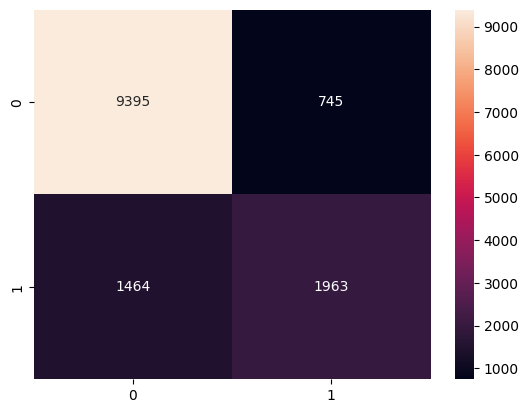

In [10]:
sns.heatmap(confusion_matrix, annot=True, fmt='g')

## Saving into DF then CSV

In [11]:
result_df = pd.DataFrame(results, columns=header)
result_df

,model_name,cv_seed,clas_acc,f1-micro,f1-macro,a1_dp,a1_deqodds,a1_deqopp,a2_dp,a2_deqodds,a2_deqopp,wc_spd,wc_aod,wc_eod
0,SkVanillaLR,13,0.841306,0.841306,0.767612,0.819360,0.885714,0.848562,0.173724,0.273774,0.173724,0.699271,0.585538,0.187500
1,SkVanillaLR,29,0.840864,0.840864,0.768534,0.814613,0.880409,0.839995,0.203813,0.264890,0.203813,0.677125,0.544623,0.083333
2,SkVanillaLR,42,0.844181,0.844181,0.777297,0.802139,0.880844,0.849245,0.221298,0.307209,0.221298,0.654612,0.637089,0.441379
3,SkVanillaLR,55,0.837989,0.837989,0.762611,0.828058,0.896273,0.859722,0.171262,0.275102,0.171262,0.721510,0.698223,0.419048
4,SkVanillaLR,73,0.837178,0.837178,0.767370,0.809251,0.892008,0.866772,0.160916,0.202745,0.160916,0.715466,0.632576,0.250000


In [12]:
result_df.to_csv(f'../results/{data_name}-unfair_lr-{epochs}.csv')